In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split
import tifffile as tiff
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from PIL import Image
from tqdm import tqdm
from torchvision import transforms
from skimage import io
import sys
# from umap import UMAP
import joblib
import pandas as pd

# Load Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(script_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.autoencoders import AE, train_ae
from core.dataset import TIFFDataset
from utils.feature_analysis import UMAP_train, patch_csv_to_AE_latent, patch_2_normed_tensor,data_to_latents, kmeans_latents,latent_to_umap,UMAP_train,DBSCAN_cluster,kmeans_cluster,dataloader_model_latents
from utils.plotting_utils import umap_2Dplot, cluster_2Dplot


In [ ]:
ae_path = '/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/results/pax_wholecell_ch1_ps32_latdim_24_20251002_2314/ae_model_ep9999.pt'
ae = torch.load(ae_path, map_location=device, weights_only=False)
ae = ae.to(device)
ae.eval()

AE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.01)
    (9): Flatten(start_dim=1, end_dim=-1)
  )
  (encoder_fc): Sequential(
    (0): Linear(in_features=2048, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=24, bias=True)
  )
  (decoder_fc): Sequential(
    (0): Linear(in_features=24, out_features=10

In [11]:
recon_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/recon_m15_00_wholecell_bn10000_ps32_latdim_24_20251002_2314'
os.makedirs(recon_dir, exist_ok=True)

raw_grid_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/raw_m15_grid_00_wholecell_bn10000_ps32_latdim_24_20251002_2314'
os.makedirs(raw_grid_dir, exist_ok=True)

raw_patch_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/raw_m15_patch_00_wholecell_bn10000_ps32_latdim_24_20251002_2314'
os.makedirs(raw_patch_dir, exist_ok=True)

recon_patch_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/recon_m15_patch_00_wholecell_bn10000_ps32_latdim_24_20251002_2314'
os.makedirs(recon_patch_dir, exist_ok=True)




In [ ]:
csv_folder = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/plot_patches32_40p_20250919_0948'
csv_filename = 'data_prep_record_49_t49.csv'
group_labels = 0
ctrl_y_str = 'ctrl'

ctrl_patch_label_df, ctrl_latent_array = patch_csv_to_AE_latent(ctrl_y_str,csv_folder,csv_filename,group_labels,ae,device)
    


In [ ]:
csv_folder = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/y_ch1_major/y_ch1_patches_gridonly_wholecell_pslocation00/plot_patches32_40p_20250919_1005'
csv_filename = 'data_prep_record_40_t40.csv'
group_labels = 1
ctrl_y_str = 'y'

y_patch_label_df, y_latent_array = patch_csv_to_AE_latent(ctrl_y_str,csv_folder,csv_filename,group_labels,ae,device)


In [ ]:
patch_label_df = pd.concat(ctrl_patch_label_df,y_patch_label_df)
latent_array = np.concatenate(ctrl_latent_array, y_latent_array)
latent_array_np = torch.stack(latent_array).detach().cpu().numpy().squeeze()
print(latent_array_np.shape)

,ctrl_y_str,crop_img_filename,group_labels,UMAP_d0,UMAP_d1,DBSCAN_labels,kmeans_labels
0,ctrl,f0000x0080y0816ps32.tif,0,0,0,0,0
1,ctrl,f0000x0112y0784ps32.tif,0,0,0,0,0
2,ctrl,f0000x0144y0784ps32.tif,0,0,0,0,0
3,ctrl,f0000x0176y0784ps32.tif,0,0,0,0,0
4,ctrl,f0000x0240y0752ps32.tif,0,0,0,0,0
...,...,...,...,...,...,...,...
23651,y,f0040x0912y0624ps32.tif,1,0,0,0,0
23652,y,f0040x0912y0656ps32.tif,1,0,0,0,0
23653,y,f0040x0912y0688ps32.tif,1,0,0,0,0
23654,y,f0040x0912y0720ps32.tif,1,0,0,0,0


In [12]:
joblib.dump(os.path.join(recon_dir, 'latent_array_np.pkl'),'latent_array_np')
patch_label_df.to_csv(os.path.join(recon_dir, 'patch_label_df.csv'))

In [14]:
eps=3
min_samples=5
result_dir = '../results/ctrl_y_ch1_patches_gridonly_wholecell_pslocation00'
os.makedirs(result_dir, exist_ok=True)


In [15]:
DBSCAN, DBSCAN_labels =  DBSCAN_cluster(latent_array_np, eps=eps, min_samples=min_samples, result_dir=result_dir)


In [ ]:
kmeans_num_clusters=3
kmeans, kmeans_labels = kmeans_cluster(latent_array_np, num_clusters=kmeans_num_clusters, result_dir=result_dir)


(array([16928.,     0.,     0.,     0.,     0.,  5704.,     0.,     0.,
            0.,  1024.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

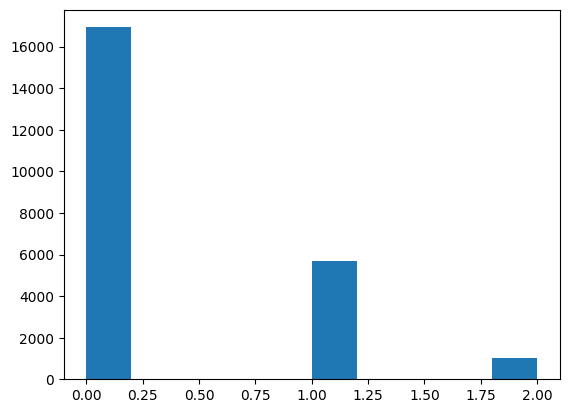

In [17]:
plt.hist(kmeans_labels)

In [18]:
latents_2d = UMAP_train(latent_array_np, result_dir)

/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [19]:
patch_label_df['kmeans_labels']= kmeans_labels
patch_label_df['DBSCAN_labels']= DBSCAN_labels


In [20]:
patch_label_df['UMAP_d1']= latents_2d[:,0]
patch_label_df['UMAP_d2']= latents_2d[:,1]
patch_label_df.to_csv(os.path.join(recon_dir, 'patch_label_df.csv'))

In [21]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_latents_2d = tsne.fit_transform(latent_array_np)

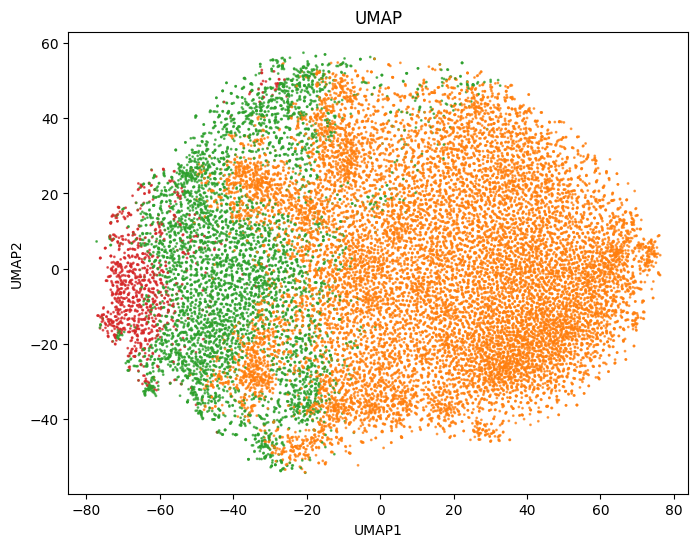

In [22]:
fig = umap_2Dplot(tsne_latents_2d, 0,1,kmeans_labels)

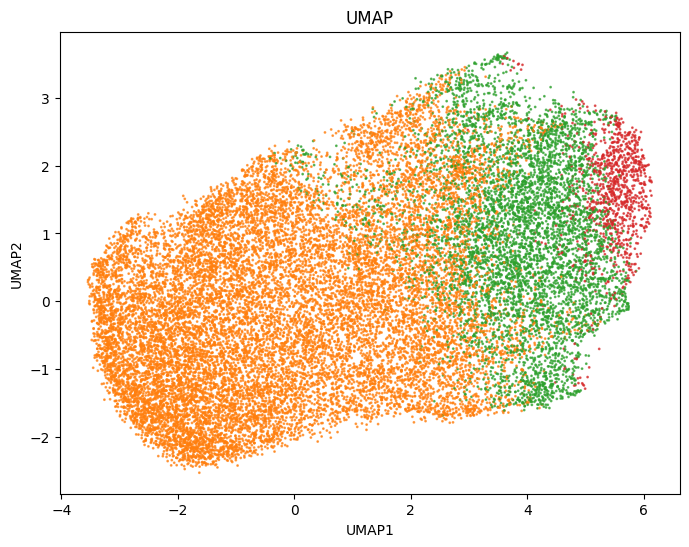

In [23]:
fig = umap_2Dplot(latents_2d, 0,1,kmeans_labels)

In [24]:
group_labels = patch_label_df['group_labels']

latents_2d[group_labels==0].shape

(12912, 2)

Text(0, 0.5, 'UMAP2')

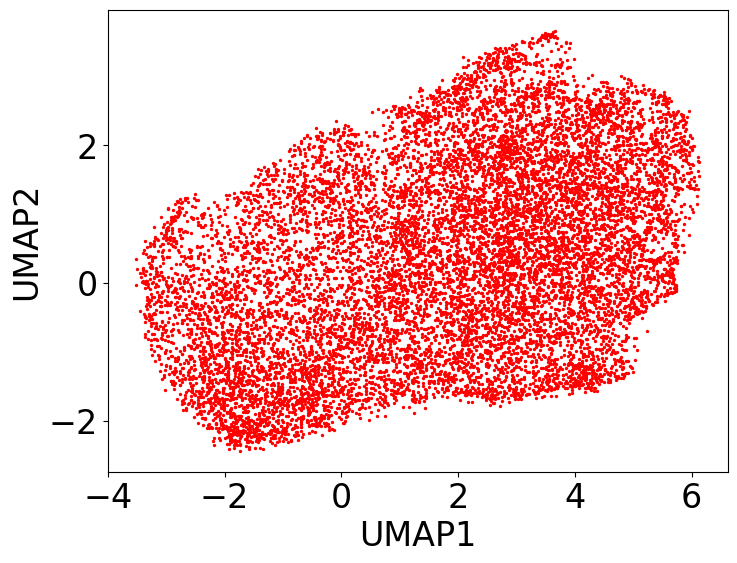

In [25]:
ctrl_latents_2d= latents_2d[group_labels==0]
y_latents_2d= latents_2d[group_labels==1]
# fig = umap_2Dplot(latents_2d[group_labels==1], 0,1,group_labels[group_labels==1]+2)
plt.rcParams.update({'font.size': 24})

fig = plt.figure(figsize=(8, 6))
plt.scatter(ctrl_latents_2d[:, 0], ctrl_latents_2d[:, 1], c='red',  s=2)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
# plt.title("UMAP")  

Text(0, 0.5, 'UMAP2')

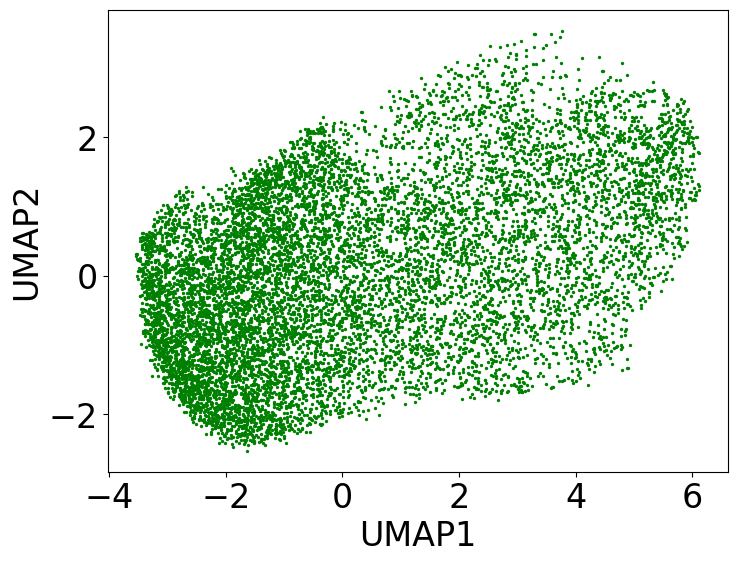

In [26]:

ctrl_latents_2d= latents_2d[group_labels==0]
y_latents_2d= latents_2d[group_labels==1]
# fig = umap_2Dplot(latents_2d[group_labels==1], 0,1,group_labels[group_labels==1]+2)
plt.rcParams.update({'font.size': 24})

fig = plt.figure(figsize=(8, 6))
plt.scatter(y_latents_2d[:, 0], y_latents_2d[:, 1], c='green',  s=2)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
# plt.title("UMAP")  


In [ ]:
csv_folder = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/plot_patches32_40p_20250919_0948'
csv_filename = 'data_prep_record_49_t49.csv'

pad_size = 64
import pandas as pd

all_image_csv = pd.read_csv(os.path.join(csv_folder,csv_filename))

unique_vals = all_image_csv["filename"].unique()
latent_array =  []
index_count=-1

for filename in unique_vals:
    this_file_csv = all_image_csv[all_image_csv["filename"]==filename]
    # print(csv_filename)
    raw_whole_image = np.zeros([1024,1024])
    recon_whole_image = np.zeros([1024,1024])    
    raw_whole_image_RGB = np.zeros([3,1024,1024])
    recon_whole_image_RGB = np.zeros([3,1024,1024])    

    for index, row in this_file_csv.iterrows():       
        index_count = index_count+1 
        x_corner1 = int(row["x_corner1"])
        x_corner3 = int(row["x_corner3"])
        y_corner1 = int(row["y_corner1"])
        y_corner3 = int(row["y_corner3"])
        patch_name = row['crop_img_filename']

                
        raw_patch = tiff.imread(os.path.join(row["movie_partitioned_data_dir"],row["crop_img_filename"] ))
        normed_raw_patch = raw_patch.copy() * 240 
        normed_raw_patch[normed_raw_patch > 254] = 254
        normed_raw_patch = normed_raw_patch/255
        
        tensor_patch = torch.from_numpy(normed_raw_patch)
        tensor_patch = tensor_patch.unsqueeze(0).unsqueeze(0)
        tensor_patch = tensor_patch.to(device)
        ae = ae.to(device)
        with torch.no_grad():
            recon_image, latent = ae(tensor_patch)
        latent_array.append(latent)        

        recon_patch_filename = 'c'+str(int(kmeans_labels[index_count])).zfill(3) +"_recon_patch_"+patch_name+'.tif'
    
        tiff.imwrite(
            os.path.join(recon_patch_dir,recon_patch_filename),
            recon_image.squeeze().cpu().detach().numpy().astype(np.float32),
            imagej=True,              # Write ImageJ metadata block
            metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
        )    
        
        raw_patch_img_filename = 'c'+str(int(kmeans_labels[index_count])).zfill(3) +"_raw_patch_"+patch_name+'.tif'
        
        tiff.imwrite(
            os.path.join(raw_patch_dir,raw_patch_img_filename),
            normed_raw_patch.astype(np.float32),
            imagej=True,              # Write ImageJ metadata block
            metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
        )

        raw_whole_image[y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] = normed_raw_patch
        recon_whole_image[y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] = recon_image.squeeze().cpu().detach()
        # recon_whole_image_RGB[0,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] = recon_image.squeeze().cpu().detach()
        # recon_whole_image_RGB[1,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] = recon_image.squeeze().cpu().detach()
        # recon_whole_image_RGB[2,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] = recon_image.squeeze().cpu().detach()
        # if(kmeans_labels[index_count]==0):
        #     recon_whole_image_RGB[0,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] =1
        # if(kmeans_labels[index_count]==1):
        #     recon_whole_image_RGB[1,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] =1
        # if(kmeans_labels[index_count]==2):
        #     recon_whole_image_RGB[2,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] =1



    # fig, ax = plt.subplots(1,2, figsize=(8,4))
    # ax[0].imshow(raw_whole_image,cmap=plt.cm.gray)
    # ax[1].imshow(recon_whole_image,cmap=plt.cm.gray)

    recon_img_filename = "recon_"+filename+'.tif'
    
    tiff.imwrite(
        os.path.join(recon_dir,recon_img_filename),
        recon_whole_image.astype(np.float32),#.swapaxes(0,2),
        imagej=True,              # Write ImageJ metadata block
        metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
    )    
    
    # raw_grid_img_filename = "raw_grid_"+filename+'.tif'
    
    # tiff.imwrite(
    #     os.path.join(raw_grid_dir,raw_grid_img_filename),
    #     raw_whole_image.astype(np.float32),
    #     imagej=True,              # Write ImageJ metadata block
    #     metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
    # )

    # break

In [ ]:
matplotlib.pyplot.imshow(recon_whole_image_RGB.swapaxes(0,2))